<a href="https://colab.research.google.com/github/vkantimahanti/healthcare-ml-portfolio/blob/main/randomforest_regression_load_diabetes_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow shap -q

'''
mlflow - Installs MLflow, an open-source platform used to manage the machine learning lifecycle, including experiment tracking, model packaging, and deployment.
shap - Installs SHAP (SHapley Additive exPlanations), a library used for "model explainability." it helps you understand how different features in your data contribute to a model's specific predictions.
-q -  A flag that tells pip to be "quiet." It hides non-error messages (like progress bars and successful download notifications) to keep your terminal or notebook output clean.
'''

import pandas as pd
import numpy as np
import mlflow
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.6 MB/s eta 0:00:00
All libraries loaded ✓


In [2]:
# Load the diabetes dataset
# This is a REGRESSION task: predict disease progression score
# 442 patients, 10 clinical features (age, sex, BMI, blood pressure, etc.)

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='disease_progression')

print(f"Dataset shape: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nTarget range: {y.min():.0f} to {y.max():.0f}")
print(f"Mean progression score: {y.mean():.1f}")
print(f"\nFirst 3 rows:")
X.head(3)

Dataset shape: (442, 10)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target range: 25 to 346
Mean progression score: 152.1

First 3 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930


In [4]:
# Split: 80% train, 20% test — standard practice
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    max_depth=5,        # prevent overfitting --can only make a maximum of 5 sequential "decisions" or branches from the top to a leaf.
    random_state=42     # Random Forests involve randomness (like picking random subsets of data and features for each tree). Setting random_state=42 ensures that this "randomness" is exactly the same every time you run your code.It makes your results reproducible. Without it, you might get a slightly different accuracy score every time you hit "Run," making it impossible to know if a change in your model's performance was due to a code tweak or just a "lucky" random split
)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
r2  = r2_score(y_test, y_pred)              #The "Efficiency" Metric. Also known as the Coefficient of Determination, it tells you what percentage of the variation in your data is explained by your model. Goal: You want this to be as close to 1 as possible.
                                            # 0.0: Your model is no better than just guessing the average value every time.
                                            # 1.0: Your model perfectly predicts every single data point.
mae = mean_absolute_error(y_test, y_pred)  # MAE tells you, on average, how far off your predictions are from the actual values. Goal: You want this to be as close to 0 as possible.

print(f"R² Score : {r2:.3f}  (1.0 = perfect, 0 = useless)")
print(f"MAE      : {mae:.1f}  (avg prediction error in score units)")
print(f"\nModel trained on {len(X_train)} patients")
print(f"Tested on {len(X_test)} patients")

R² Score : 0.456  (1.0 = perfect, 0 = useless)
MAE      : 43.6  (avg prediction error in score units)

Model trained on 353 patients
Tested on 89 patients


In [5]:
# MLflow tracks every experiment so you can compare models later
# This habit separates engineers from notebook experimenters

mlflow.set_experiment("diabetes-progression")

with mlflow.start_run(run_name="random-forest-baseline"):
    # Log parameters (what settings you used)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("test_size", 0.2)

    # Log metrics (how well it performed)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("mae", mae)

    # Log the model itself
    mlflow.sklearn.log_model(model, "random-forest-model")

print("Experiment logged to MLflow ✓")
print(f"R²: {r2:.3f} | MAE: {mae:.1f}")

2026/03/14 18:42:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/14 18:42:59 INFO mlflow.store.db.utils: Updating database tables
2026/03/14 18:43:01 INFO mlflow.tracking.fluent: Experiment with name 'diabetes-progression' does not exist. Creating a new experiment.
2026/03/14 18:43:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:43:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment logged to MLflow ✓
R²: 0.456 | MAE: 43.6


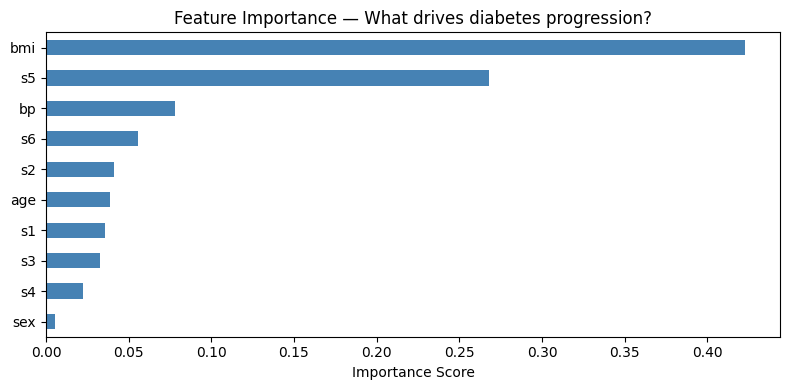

Plot saved as feature_importance.png ✓


In [6]:
# Which features drive disease progression?
# This is what a doctor or product manager will ask you first
# pd.series: This maps those scores to your actual column names (e.g., "bmi", "age") so you know which bar belongs to which feature.
importances = pd.Series(
    model.feature_importances_,  # This extracts the "scores" from your Random Forest. A higher score means the model relied on that specific feature more heavily to make its guess.
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — What drives diabetes progression?')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Plot saved as feature_importance.png ✓")